<a href="https://colab.research.google.com/github/lamiya123-art/internship-persevex/blob/main/datacleaning(miniproject_2)_%3Ewinsorisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest
from scipy.stats.mstats import winsorize


In [ ]:
data = np.array([10,20,30,400,700])
zscores = np.abs(stats.zscore(data))
outliers = data[(zscores > 3)]
print("outliers:", outliers)

outliers: []


In [9]:
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)
IQR = q3-q1
outliers = data[(data < (q1 - 1.5 * IQR)) | (data > (q3 + 1.5 * IQR))]

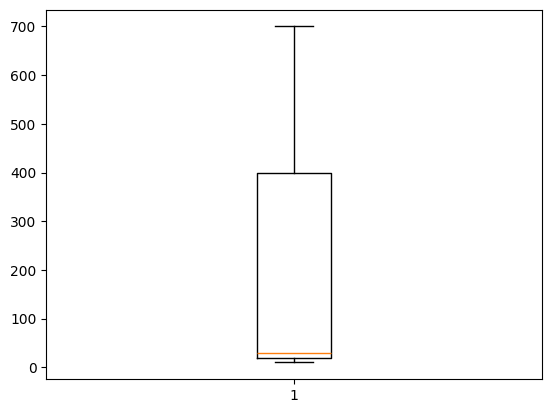

In [11]:
import matplotlib.pyplot as plt
plt.boxplot(data)
plt.show()

In [12]:
winsorised_data = winsorize(data, limits=[0.05,0.05])

In [15]:
print("Winsorized data:", winsorised_data)

Winsorized data: [ 10  20  30 400 700]


In [16]:
clf = IsolationForest(contamination=0.4)

In [17]:
pred = clf.fit_predict(data.reshape(-1, 1))
data_no_outliers = data[pred == 1]

print(f"Data after removing outliers using Isolation Forest: {data_no_outliers}")

Data after removing outliers using Isolation Forest: [10 20 30]
